# Scaffold analysis
We take only the core ("scaffold") and forget all side chains.
We try to reduce chemical structures to their main structural motif.

* Murcko scaffold - the core is the largest connected component of the molecule.
* Generic scaffold - every heteroatom is replaced by carbon, and all bond orders are set to single.

In [2]:
import pandas as pd
from numpy.ma.extras import column_stack

df = pd.read_csv('../my_data/structures_best.csv', usecols=['Canonical_SMILES', 'Source'])
df

,Canonical_SMILES,Source
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,DrugBank
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DrugBank
2,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,DrugBank
3,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DrugBank
4,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,DrugBank
...,...,...
18891,CCc1ncc(C(=O)NCC2CCC(NC(=O)c3ncncc3N)CC2)s1,ZINC
18892,O=C(N[C@]12CCC[C@@H]1N(C[C@@H]1CCCCO1)CC2)c1cc...,ZINC
18893,Cc1ocnc1C(=O)Nc1cccc(CNC(=O)[C@H](C)n2ccc(C3CC...,ZINC
18894,CC(C)(CF)C(=O)N1CC2(CC[C@H](CNC(=O)c3ccnc(Cl)c...,ZINC


Let's compute the Murcko Scaffold and the Generic Scaffold for each molecule.

In [6]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# 1. Add RDKit Mol column
df['RDKit Mol'] = df['Canonical_SMILES'].apply(Chem.MolFromSmiles)

# Function to get Murcko Scaffold SMILES
def get_murcko(mol):
    if mol:
        try:
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            return Chem.MolToSmiles(scaffold)
        except:
            return None
    return None

# Function to get Generic Scaffold SMILES (Carbon-only framework)
def get_generic(mol):
    if mol:
        try:
            # First get the scaffold, then make it generic
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            generic = MurckoScaffold.MakeScaffoldGeneric(scaffold)
            return Chem.MolToSmiles(generic)
        except:
            return None
    return None

# 2. Compute Scaffold
df['Scaffold'] = df['RDKit Mol'].apply(get_murcko)

# 3. Compute Generic Scaffold
df['Generic Scaffold'] = df['RDKit Mol'].apply(get_generic)

# Display results
print(df[['Canonical_SMILES', 'Scaffold', 'Generic Scaffold']].head())

[12:13:19] Explicit valence for atom # 3 C, 5, is greater than permitted
[12:13:19] Explicit valence for atom # 3 C, 5, is greater than permitted
[12:13:20] Explicit valence for atom # 30 C, 6, is greater than permitted
[12:13:20] Explicit valence for atom # 14 C, 10, is greater than permitted
[12:13:20] Explicit valence for atom # 10 C greater than permitted
[12:13:20] Explicit valence for atom # 11 C greater than permitted
[12:13:21] Explicit valence for atom # 11 C greater than permitted
[12:13:21] Explicit valence for atom # 31 C, 5, is greater than permitted
[12:13:21] Explicit valence for atom # 30 C, 6, is greater than permitted


                                    Canonical_SMILES  \
0  CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...   
1  CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...   
2  N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...   
3  CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...   
4  C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...   

                                            Scaffold  \
0  O=C(CNC(=O)CNC(=O)[C@@H]1CCCN1C(=O)CNC(=O)CNC(...   
1  O=C(CNC(=O)CNC(=O)[C@H](Cc1ccccc1)NC(=O)CNC(=O...   
2  O=C1CNC(=O)[C@H](Cc2ccccc2)NC(=O)[C@H](Cc2cccc...   
3  O=C(CNC(=O)CNC(=O)[C@H](Cc1ccccc1)NC(=O)CNC(=O...   
4  O=C1CNC(=O)CNC(=O)CNC(=O)CNC(=O)CNC(=O)CNC(=O)...   

                                    Generic Scaffold  
0  CC(CCCC1CCCCC1)CCC(C)CCC(C)C1CCCC1C(C)CCC(C)CC...  
1  CC(CCC(C)CCC(C)C(CC(C)CCC(C)C(CC(C)C(CC1CCCC1)...  
2  CC1CCC(C)CC(C(C)C2CCCC2)CCCCCC(C)CC(CC2CCCCC2)...  
3  CC(CCC(C)CCC(C)C(CC(C)CCC(C)C(CC1CCCCC1)CC(C)C...  
4  CC1CCC(C)CCC(C)CCC(C)CCC(C)CCC(C)CCC(C)CCC(C)C..

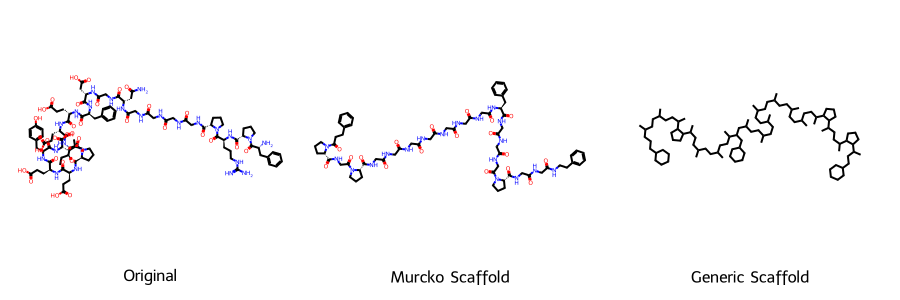

In [9]:
from rdkit.Chem import Draw

def draw_scaffold_comparison(df, row_id):
    """
    Draws the original molecule, its Murcko scaffold, and its generic scaffold.
    """
    row = df.iloc[row_id]

    # Get SMILES strings
    smiles_list = [
        row['Canonical_SMILES'],
        row['Scaffold'],
        row['Generic Scaffold']
    ]

    # Convert SMILES to Mol objects (filter out None values)
    mols = [Chem.MolFromSmiles(s) for s in smiles_list if s is not None]

    # Create labels
    labels = ["Original", "Murcko Scaffold", "Generic Scaffold"]

    # Draw the grid
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=3,
        subImgSize=(300, 300),
        legends=labels[:len(mols)]
    )

    return img

draw_scaffold_comparison(df, 0)

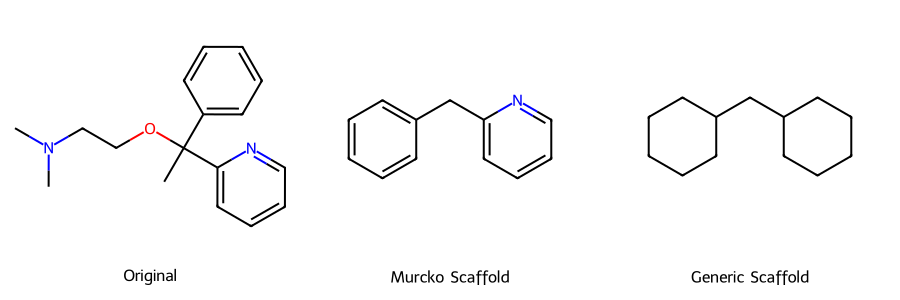

In [10]:
draw_scaffold_comparison(df, 256)

Now we would like to aggregate to data using the Generic Scaffold SMILES.

Top 5 Generic Scaffolds by Frequency:


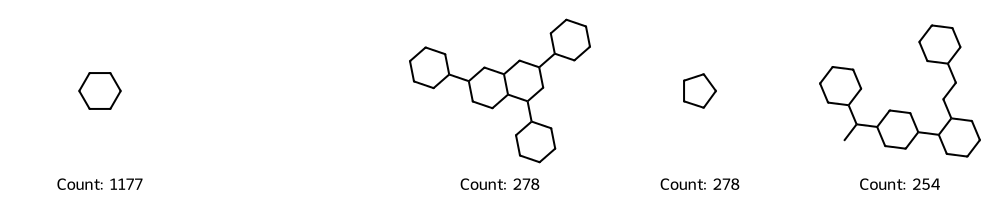

In [11]:
# 1. Count occurrences of each Generic Scaffold
scaffold_counts = df['Generic Scaffold'].value_counts().reset_index()
scaffold_counts.columns = ['Generic Scaffold', 'Count']

# 2. To see the distribution by Source
aggregation = df.groupby(['Generic Scaffold', 'Source']).size().unstack(fill_value=0)
aggregation['Total'] = aggregation.sum(axis=1)
aggregation = aggregation.sort_values(by='Total', ascending=False)

# 3. Visualize the top 5 most frequent Generic Scaffolds
from rdkit.Chem import Draw

top_scaffolds_smiles = aggregation.head(5).index.tolist()
top_mols = [Chem.MolFromSmiles(s) for s in top_scaffolds_smiles]
top_counts = aggregation['Total'].head(5).astype(str).tolist()

print("Top 5 Generic Scaffolds by Frequency:")
Draw.MolsToGridImage(top_mols, legends=[f"Count: {c}" for c in top_counts], molsPerRow=5)

In [16]:
# Get total counts and a list of sources for each scaffold
summary_table = df.groupby('Generic Scaffold').agg({
    'Source': lambda x: ', '.join(x.unique()),
    'Canonical_SMILES': 'count'
}).reset_index()

summary_table.columns = ['scaffold', 'source', 'count']
summary_table = summary_table.sort_values(by='count', ascending=False)

summary_table.head()

,scaffold,source,count
1129,C1CCCCC1,"DrugBank, ZINC",1177
0,,"DrugBank, ZINC",1013
379,C1CCC(C2CCC3C(C2)CC(C2CCCCC2)CC3C2CCCCC2)CC1,ChEMBL,278
1127,C1CCCC1,"DrugBank, ZINC",278
1769,CC(C1CCCCC1)C1CCC(C2CCCCC2CCC2CCCCC2)CC1,ChEMBL,254


In [23]:
# 1. Calculate the total number of rows in the dataset
total_rows = len(df)

# 2. Group by scaffold and source to get counts
scaffold_table = df.groupby(['Generic Scaffold', 'Source']).size().reset_index(name='count')

# 3. Calculate percentage based on the total dataset size
# We use 100.0 to ensure float division
scaffold_table['percentage'] = (scaffold_table['count'] / total_rows) * 100

# 4. Cleanup: Rename columns and sort
scaffold_table.rename(columns={'Generic Scaffold': 'scaffold', 'Source': 'source'}, inplace=True)
scaffold_table = scaffold_table.sort_values(by='count', ascending=False)

# 5. Display only a small portion to avoid the IOPub data rate error
# We'll format the percentage to 2 decimal places for readability
pd.options.display.float_format = '{:.2f}%'.format
reduced = scaffold_table.head(20)
reduced

,scaffold,source,count,percentage
0,,DrugBank,983,5.20%
1244,C1CCCCC1,DrugBank,958,5.07%
397,C1CCC(C2CCC3C(C2)CC(C2CCCCC2)CC3C2CCCCC2)CC1,ChEMBL,278,1.47%
1901,CC(C1CCCCC1)C1CCC(C2CCCCC2CCC2CCCCC2)CC1,ChEMBL,254,1.34%
1245,C1CCCCC1,ZINC,219,1.16%
932,C1CCC(CCC2CCCCC2C2CCCCC2)CC1,ChEMBL,185,0.98%
769,C1CCC(CC2CCCCC2)CC1,DrugBank,142,0.75%
1242,C1CCCC1,ZINC,139,0.74%
1241,C1CCCC1,DrugBank,139,0.74%
775,C1CCC(CC2CCCCC2C2CCCCC2)CC1,ChEMBL,132,0.70%


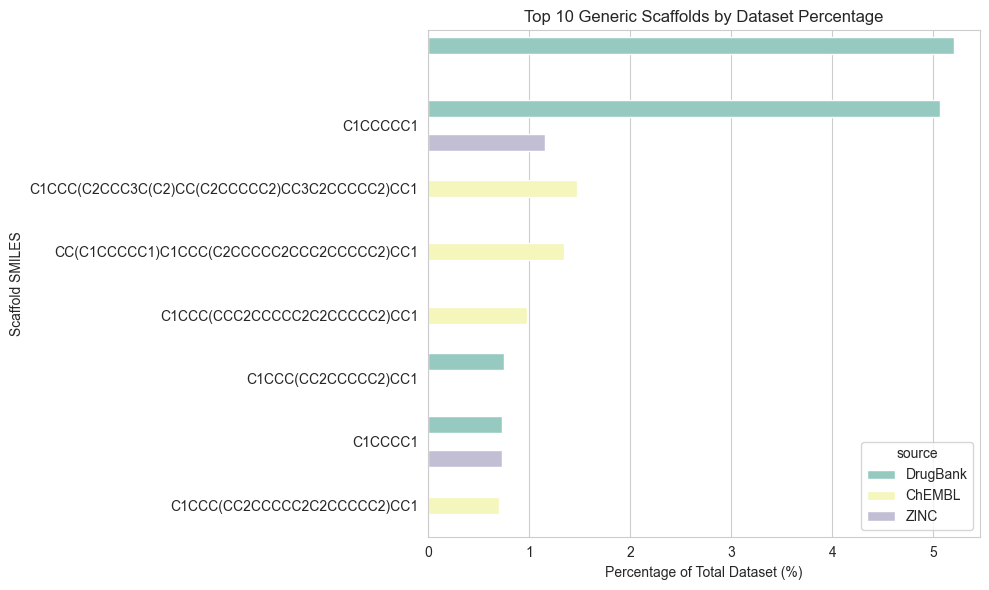

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))
sns.barplot(data=reduced.head(10), x='percentage', y='scaffold', hue='source')

plt.title('Top 10 Generic Scaffolds by Dataset Percentage')
plt.xlabel('Percentage of Total Dataset (%)')
plt.ylabel('Scaffold SMILES')
plt.tight_layout()
plt.show()

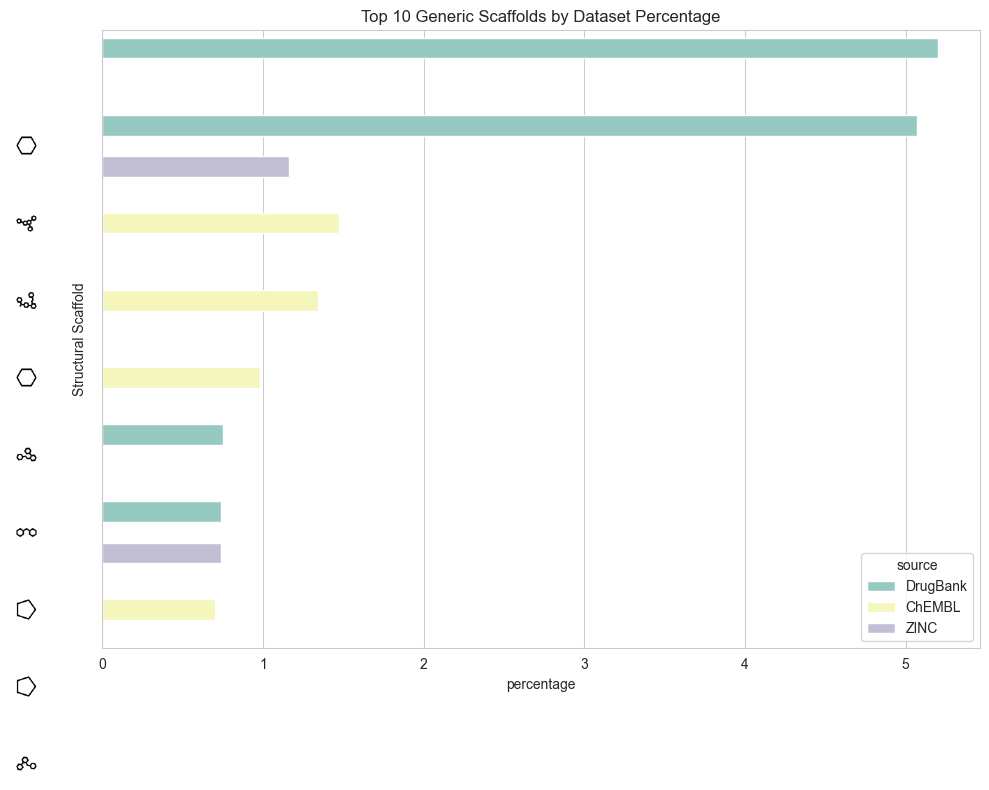

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

top10_data = reduced.head(10)
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 8)) # Increased height slightly for images

# Draw the bars
sns.barplot(data=top10_data, x='percentage', y='scaffold', hue='source', ax=ax)

# Remove the default text labels on Y-axis
ax.set_yticklabels([])
ax.set_ylabel('Structural Scaffold') # Update label

# Set titles and labels
plt.title('Top 10 Generic Scaffolds by Dataset Percentage')
plt.xlabel('Percentage of Total Dataset (%)')

# ---------------------------------------------------------
# New Code to embed molecular structures on Y-axis
# ---------------------------------------------------------

for i, scaffold_smiles in enumerate(top10_data['scaffold']):
    # Convert SMILES to RDKit Mol object
    mol = Chem.MolFromSmiles(scaffold_smiles)

    if mol:
        # Generate image for the scaffold (adjust size as needed)
        # We increase image size slightly and use zoom to maintain clarity
        img = Draw.MolToImage(mol, size=(30, 30))

        # Create an OffsetImage object with the molecule drawing
        imagebox = OffsetImage(img, zoom=0.5)

        # Place the image box at the Y-tick location (0, i)
        # xybox defines the offset of the image from the point (0, i)
        ab = AnnotationBbox(imagebox, (0, i),
                            xybox=(-55, 0), # Offset to the left
                            xycoords=('data', 'data'),
                            boxcoords="offset points",
                            frameon=False) # Remove box frame

        # Add the image to the plot axes
        ax.add_artist(ab)

# Handle potential overlapping if bars are too tall
plt.tight_layout()
plt.show()